In [19]:
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules
)
import scanpy as sc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

In [20]:
ad = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [21]:
ad

AnnData object with n_obs × n_vars = 25660 × 18751
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'sample_id', 'n_genes', 'leiden', 'treatment', 'barcode', 'region_annotation', 'leiden_0.5', 'leiden_0.75', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'PIG_score', 'OLIG_score'
    var: 'n_cells'
    uns: 'dendrogram_treatment', 'leiden', 'leiden_0.5_colors', 'leiden_0.75_colors', 'leiden_1.5_colors', 'leiden_1_colors', 'leiden_2.5_colors', 'leiden_2_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'region_annotation_colors', 'sample_id_colors', 'spatial', 'spatial_metadata_per_sample', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [24]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

# --- sanity checks ---
assert "spatial" in ad.obsm, "Missing ad.obsm['spatial']"
assert "region_annotation" in ad.obs, "Missing ad.obs['region_annotation']"

coords = np.asarray(ad.obsm["spatial"])[:, :2]

# per-sample min-max scale of coords (helps across sections)
if "sample_id" in ad.obs:
    coords_scaled = np.zeros_like(coords, dtype=float)
    for s, idx in ad.obs.groupby("sample_id").indices.items():
        block = coords[idx]
        mn = block.min(axis=0, keepdims=True)
        mx = block.max(axis=0, keepdims=True)
        denom = np.where((mx - mn) == 0, 1, (mx - mn))
        coords_scaled[idx] = (block - mn) / denom
else:
    mn = coords.min(axis=0, keepdims=True)
    mx = coords.max(axis=0, keepdims=True)
    denom = np.where((mx - mn) == 0, 1, (mx - mn))
    coords_scaled = (coords - mn) / denom

# training mask = annotated spots
mask_train = ad.obs["region_annotation"].notna().values
if mask_train.sum() == 0:
    raise ValueError("No annotated spots found in ad.obs['region_annotation'].")

X_train = coords_scaled[mask_train]
y_train = ad.obs.loc[mask_train, "region_annotation"].astype(str).values

# guard: need at least 2 classes to train kNN
if len(np.unique(y_train)) < 2:
    raise ValueError("Need ≥2 distinct region_annotation classes to train kNN.")

# test set = all spots
X_all = coords_scaled

# fit & predict
clf = KNeighborsClassifier(n_neighbors=15, weights="distance")
clf.fit(X_train, y_train)

ad.obs["region_pred"] = pd.Categorical(clf.predict(X_all), categories=np.unique(y_train))

# confidence = max class probability
probs = clf.predict_proba(X_all)
ad.obs["region_pred_conf"] = probs.max(axis=1)

# QC on already-labeled spots
from sklearn.metrics import accuracy_score, confusion_matrix
y_true = ad.obs.loc[mask_train, "region_annotation"].astype(str).values
y_pred_train = ad.obs.loc[mask_train, "region_pred"].astype(str).values
acc = accuracy_score(y_true, y_pred_train)
cm = pd.DataFrame(
    confusion_matrix(y_true, y_pred_train, labels=np.unique(y_train)),
    index=np.unique(y_train), columns=np.unique(y_train)
)
print(f"[QC] Agreement on labeled spots: {acc:.3f} (n={mask_train.sum()})")
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# optional: clear low-confidence predictions
thr = 0.5  # adjust 0.5–0.7 as you like
low = ad.obs["region_pred_conf"] < thr
ad.obs.loc[low, "region_pred"] = pd.Categorical([None]*low.sum(), categories=np.unique(y_train))
print(f"Set {low.sum()} low-confidence predictions to NA (conf < {thr}).")

[QC] Agreement on labeled spots: 1.000 (n=17429)
Confusion matrix (rows=true, cols=pred):
                       Amygdala  Caudoputamen  Corpus Callosum  Cortex L1  \
Amygdala                   274             0                0          0   
Caudoputamen                 0           576                0          0   
Corpus Callosum              0             0             1071          0   
Cortex L1                    0             0                0        787   
Cortex L2/3                  0             0                0          0   
Cortex L2/3/4                0             0                0          0   
Cortex L4/5                  0             0                0          0   
Cortex L4/5/6                0             0                0          0   
Cortex L5/6                  0             0                0          0   
Excluded                     0             0                0          0   
Hippocampus                  0             0                0          0 

In [25]:
ad

AnnData object with n_obs × n_vars = 25660 × 18751
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'sample_id', 'n_genes', 'leiden', 'treatment', 'barcode', 'region_annotation', 'leiden_0.5', 'leiden_0.75', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'PIG_score', 'OLIG_score', 'region_pred', 'region_pred_conf'
    var: 'n_cells'
    uns: 'dendrogram_treatment', 'leiden', 'leiden_0.5_colors', 'leiden_0.75_colors', 'leiden_1.5_colors', 'leiden_1_colors', 'leiden_2.5_colors', 'leiden_2_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'region_annotation_colors', 'sample_id_colors', 'spatial', 'spatial_metadata_per_sample', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

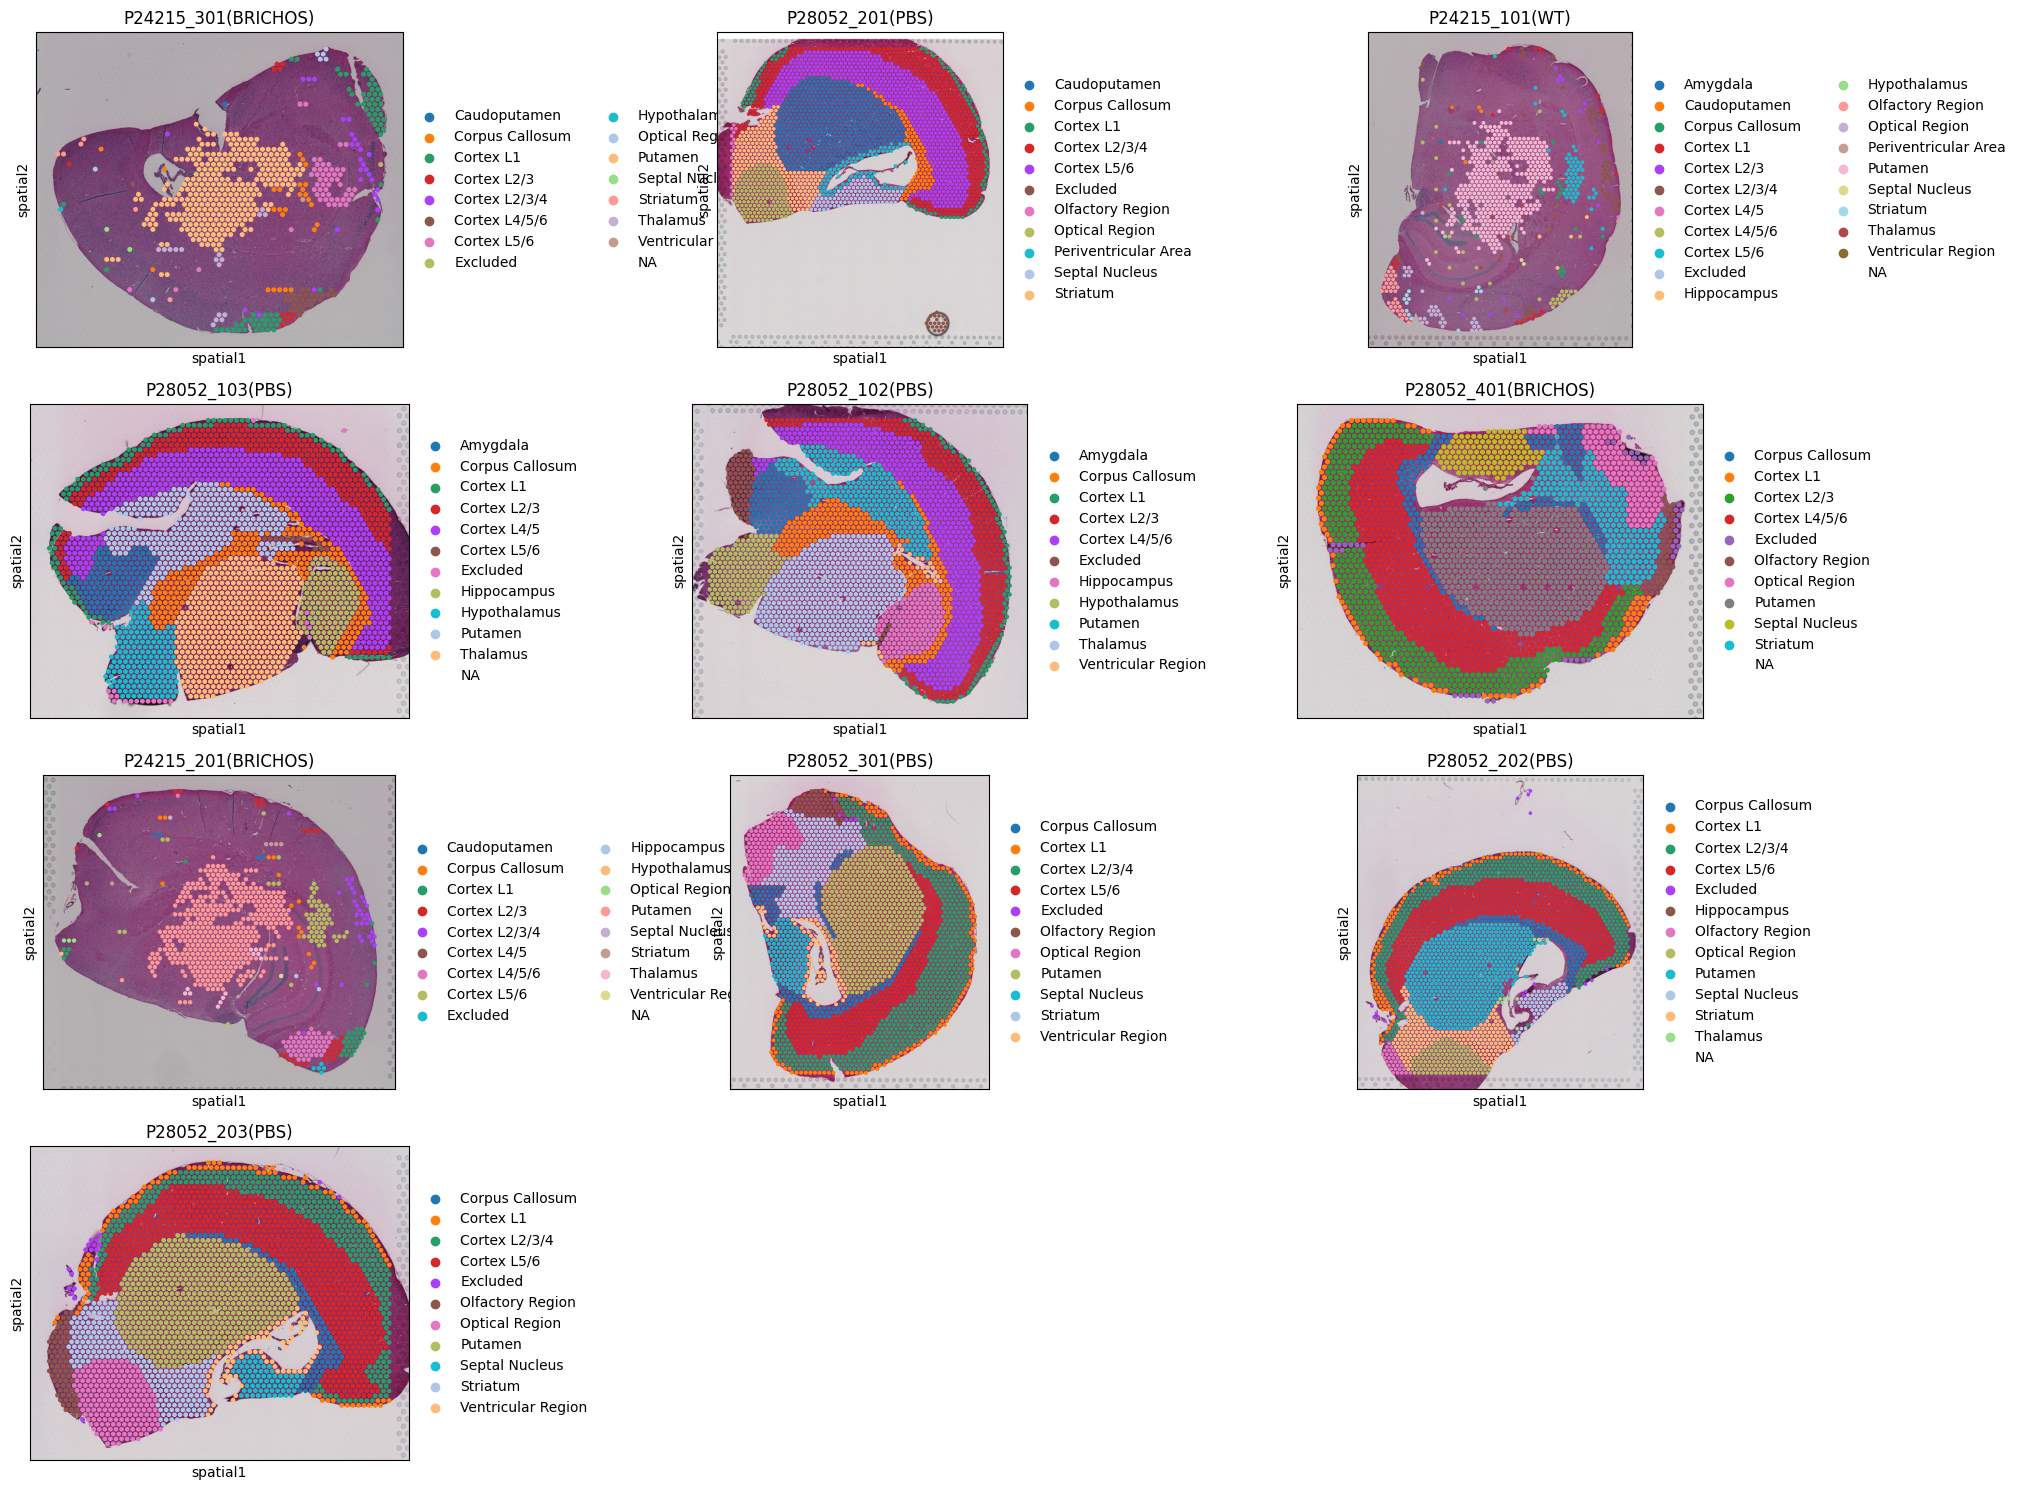

In [26]:
plot_spatial_clusters_per_sample(ad, color = 'region_pred', figsize=(20,15))

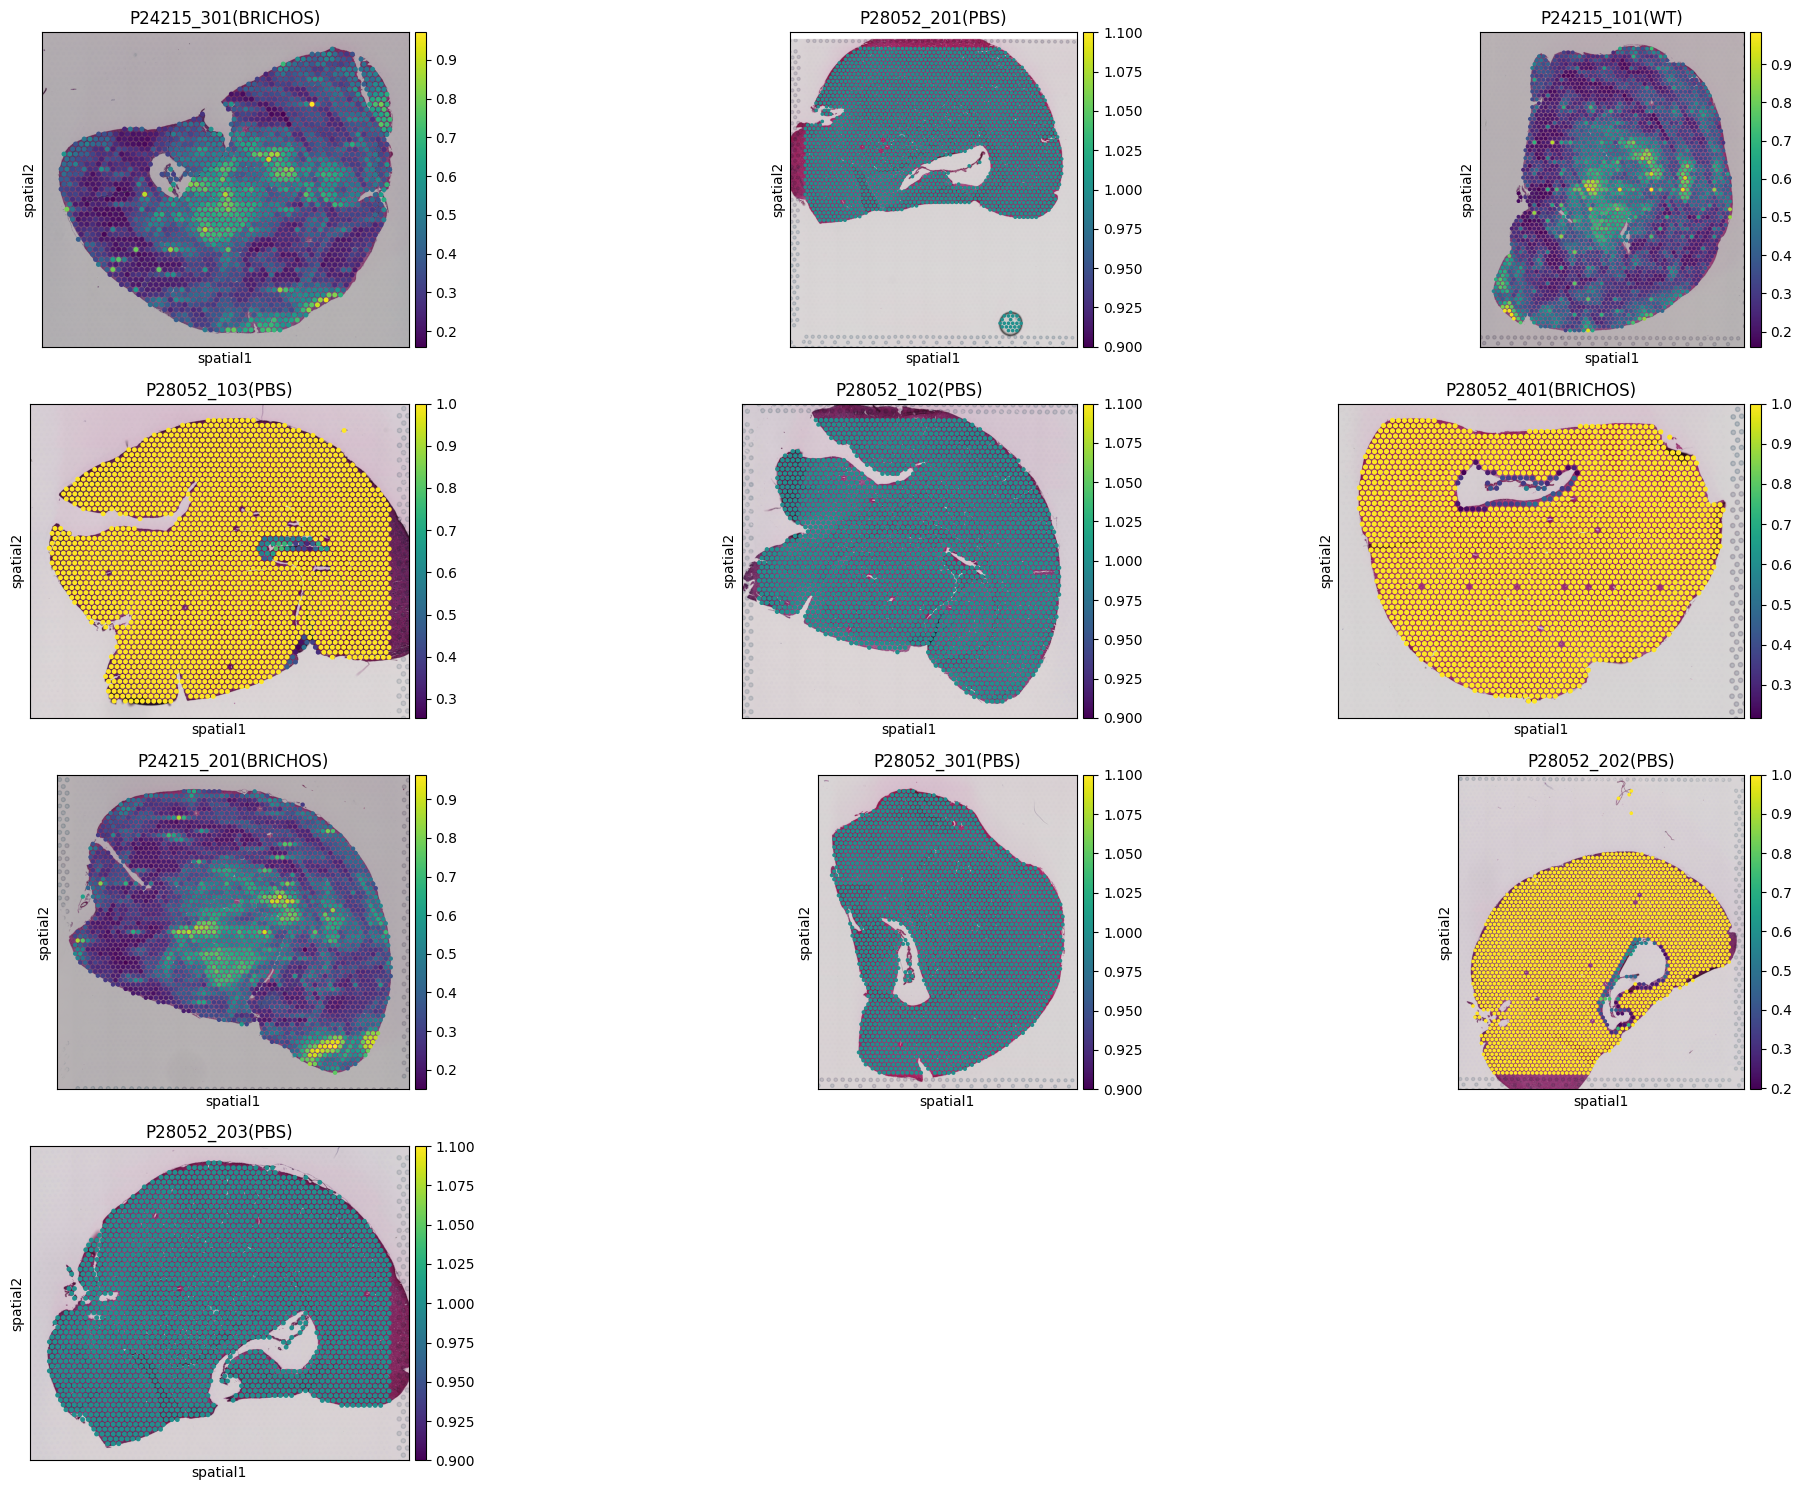

In [27]:
plot_spatial_clusters_per_sample(ad, color = 'region_pred_conf', figsize=(20,15))